# Cox生存分析

* `mydir`：自己的数据
* `ostime_column`: 数据对应的生存时间，不一定非的是OST，也可以是DST、FST等。
* `os`：生存状态，不一定非的是OS，也可以是DS、FS等。

In [1]:
from lifelines import CoxPHFitter
import pandas as pd
from onekey_algo.custom.components.comp1 import normalize_df
from sklearn.model_selection import train_test_split
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.components.comp1 import fillna

event_col = get_param_in_cwd('event_col')
duration_col = get_param_in_cwd('duration_col')
task_type = f'Combined_'
clinical = pd.read_csv(f'features/Clinical_rad_features_mulsel.csv')

clinical = pd.read_csv(f'results/Clinical_cox_predictions.csv')[['ID', 'expectation']]
clinical.columns = ['ID', 'Clinical']

rad = pd.read_csv(f'results/Pathomics_cox_predictions.csv')[['ID', 'expectation']]
rad.columns = ['ID', 'Pathomics']
survival_data = pd.read_csv(get_param_in_cwd('label_file'))[['ID', event_col, duration_col, 'group']]
data = pd.merge(clinical, rad, on='ID', how='inner')
data = pd.merge(data, survival_data, on='ID', how='inner')
data

,ID,Clinical,Pathomics,event,duration,group
0,J07A3054,138.600,131.529,0,132,train
1,J07A3055,130.586,137.326,0,131,train
2,J07A3056,120.398,137.054,1,78,train
3,J07A3057,124.339,137.326,0,131,train
4,J07A3060,114.160,135.397,0,130,train
...,...,...,...,...,...,...
273,J07A1132,134.498,136.331,0,108,test
274,J07A1133,130.586,132.938,0,107,test
275,J07A1062,132.666,136.677,0,119,test
276,J07A1080,135.418,136.273,0,115,test


In [2]:
import numpy as np
import onekey_algo.custom.components as okcomp
from collections import OrderedDict

group_info = 'group'
train_data = data[(data[group_info] == 'train')]

# subsets = [s for s in label_data['group'].value_counts().index if s != 'train']
subsets = get_param_in_cwd('subsets')
val_datasets = OrderedDict()
for subset in subsets:
    val_data = data[data[group_info] == subset]
    val_datasets[subset] = val_data
    val_data.to_csv(f'features/{task_type}{subset}_features_norm.csv', index=False)

print('，'.join([f"{subset}样本数：{d_.shape}" for subset, d_ in val_datasets.items()]))

train样本数：(194, 6)，test样本数：(84, 6)


In [3]:
import os
from onekey_algo.custom.components.survival import uni_cox

if os.path.exists(f'features/{task_type}rad_features_unisel.csv') and False:
    train_data = pd.read_csv(f'features/{task_type}rad_features_unisel.csv')
else:
    sel_features = uni_cox(train_data, duration_col=duration_col, event_col=event_col,
                           cols=[c for c in train_data.columns if c not in [event_col, duration_col, 'ID', 'group']], 
                           verbose=False)
    train_data = train_data[['ID'] + sel_features + [event_col, duration_col, 'group']]
    train_data.to_csv(f'features/{task_type}rad_features_unisel.csv', header=True, index=False)
train_data

,ID,Clinical,Pathomics,event,duration,group
0,J07A3054,138.600,131.529,0,132,train
1,J07A3055,130.586,137.326,0,131,train
2,J07A3056,120.398,137.054,1,78,train
3,J07A3057,124.339,137.326,0,131,train
4,J07A3060,114.160,135.397,0,130,train
...,...,...,...,...,...,...
189,J07A1125,132.763,125.042,0,109,train
190,J07A1130,106.928,83.304,1,9,train
191,J07A0929,132.153,126.905,0,150,train
192,J07A0934,136.853,134.031,0,149,train


## Cox概览

所有Cox回归的必要数据，主要关注的数据有3个
1. `Concordance`: c-index
2. `exp(coef)`: 每个特征对应的HR，同时也有期对应的95%分位数。
3. `p`: 表示特征是否显著。

In [4]:
from lifelines import CoxPHFitter
mci = 0
for p in range(100):
    cph = CoxPHFitter(penalizer=p/100)
    cph.fit(train_data[[c for c in train_data.columns if c not in ['ID', 'group']]], duration_col=duration_col, event_col=event_col)
    test_data = val_datasets['test']
    ci = cph.score(test_data[[c for c in test_data.columns if c not in ['ID', 'group']]], scoring_method="concordance_index")
    if mci < ci:
        print(p, ci)
        mci = ci

0 0.8322056833558863
1 0.8335588633288228


In [5]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.0)
cph.fit(train_data[[c for c in train_data.columns if c not in ['ID', 'group']]], duration_col=duration_col, event_col=event_col)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 194 total observations, 139 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 194
number of events observed = 55
   partial log-likelihood = -224.68
         time fit was run = 2025-09-12 15:15:11 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
Clinical   -0.03       0.97       0.01            -0.05            -0.01                 0.95                 0.99
Pathomics  -0.04       0.96       0.00            -0.05            -0.03                 0.95                 0.97

            cmp to     z      p   -log2(p)
covariate                                 
Clinical      0.00 -3.55 <0.005      11.35
Pathomics     0.00 -9.10 <0.005      63.25
---
Concordance = 0.83
Partial AIC = 453.37
log-likelihood ratio test = 105.94 on 2 df
-log2(p) of ll-ratio test = 76.42

#### 输出每个特征的HR

In [6]:
cph.concordance_index_

0.8340650681076213

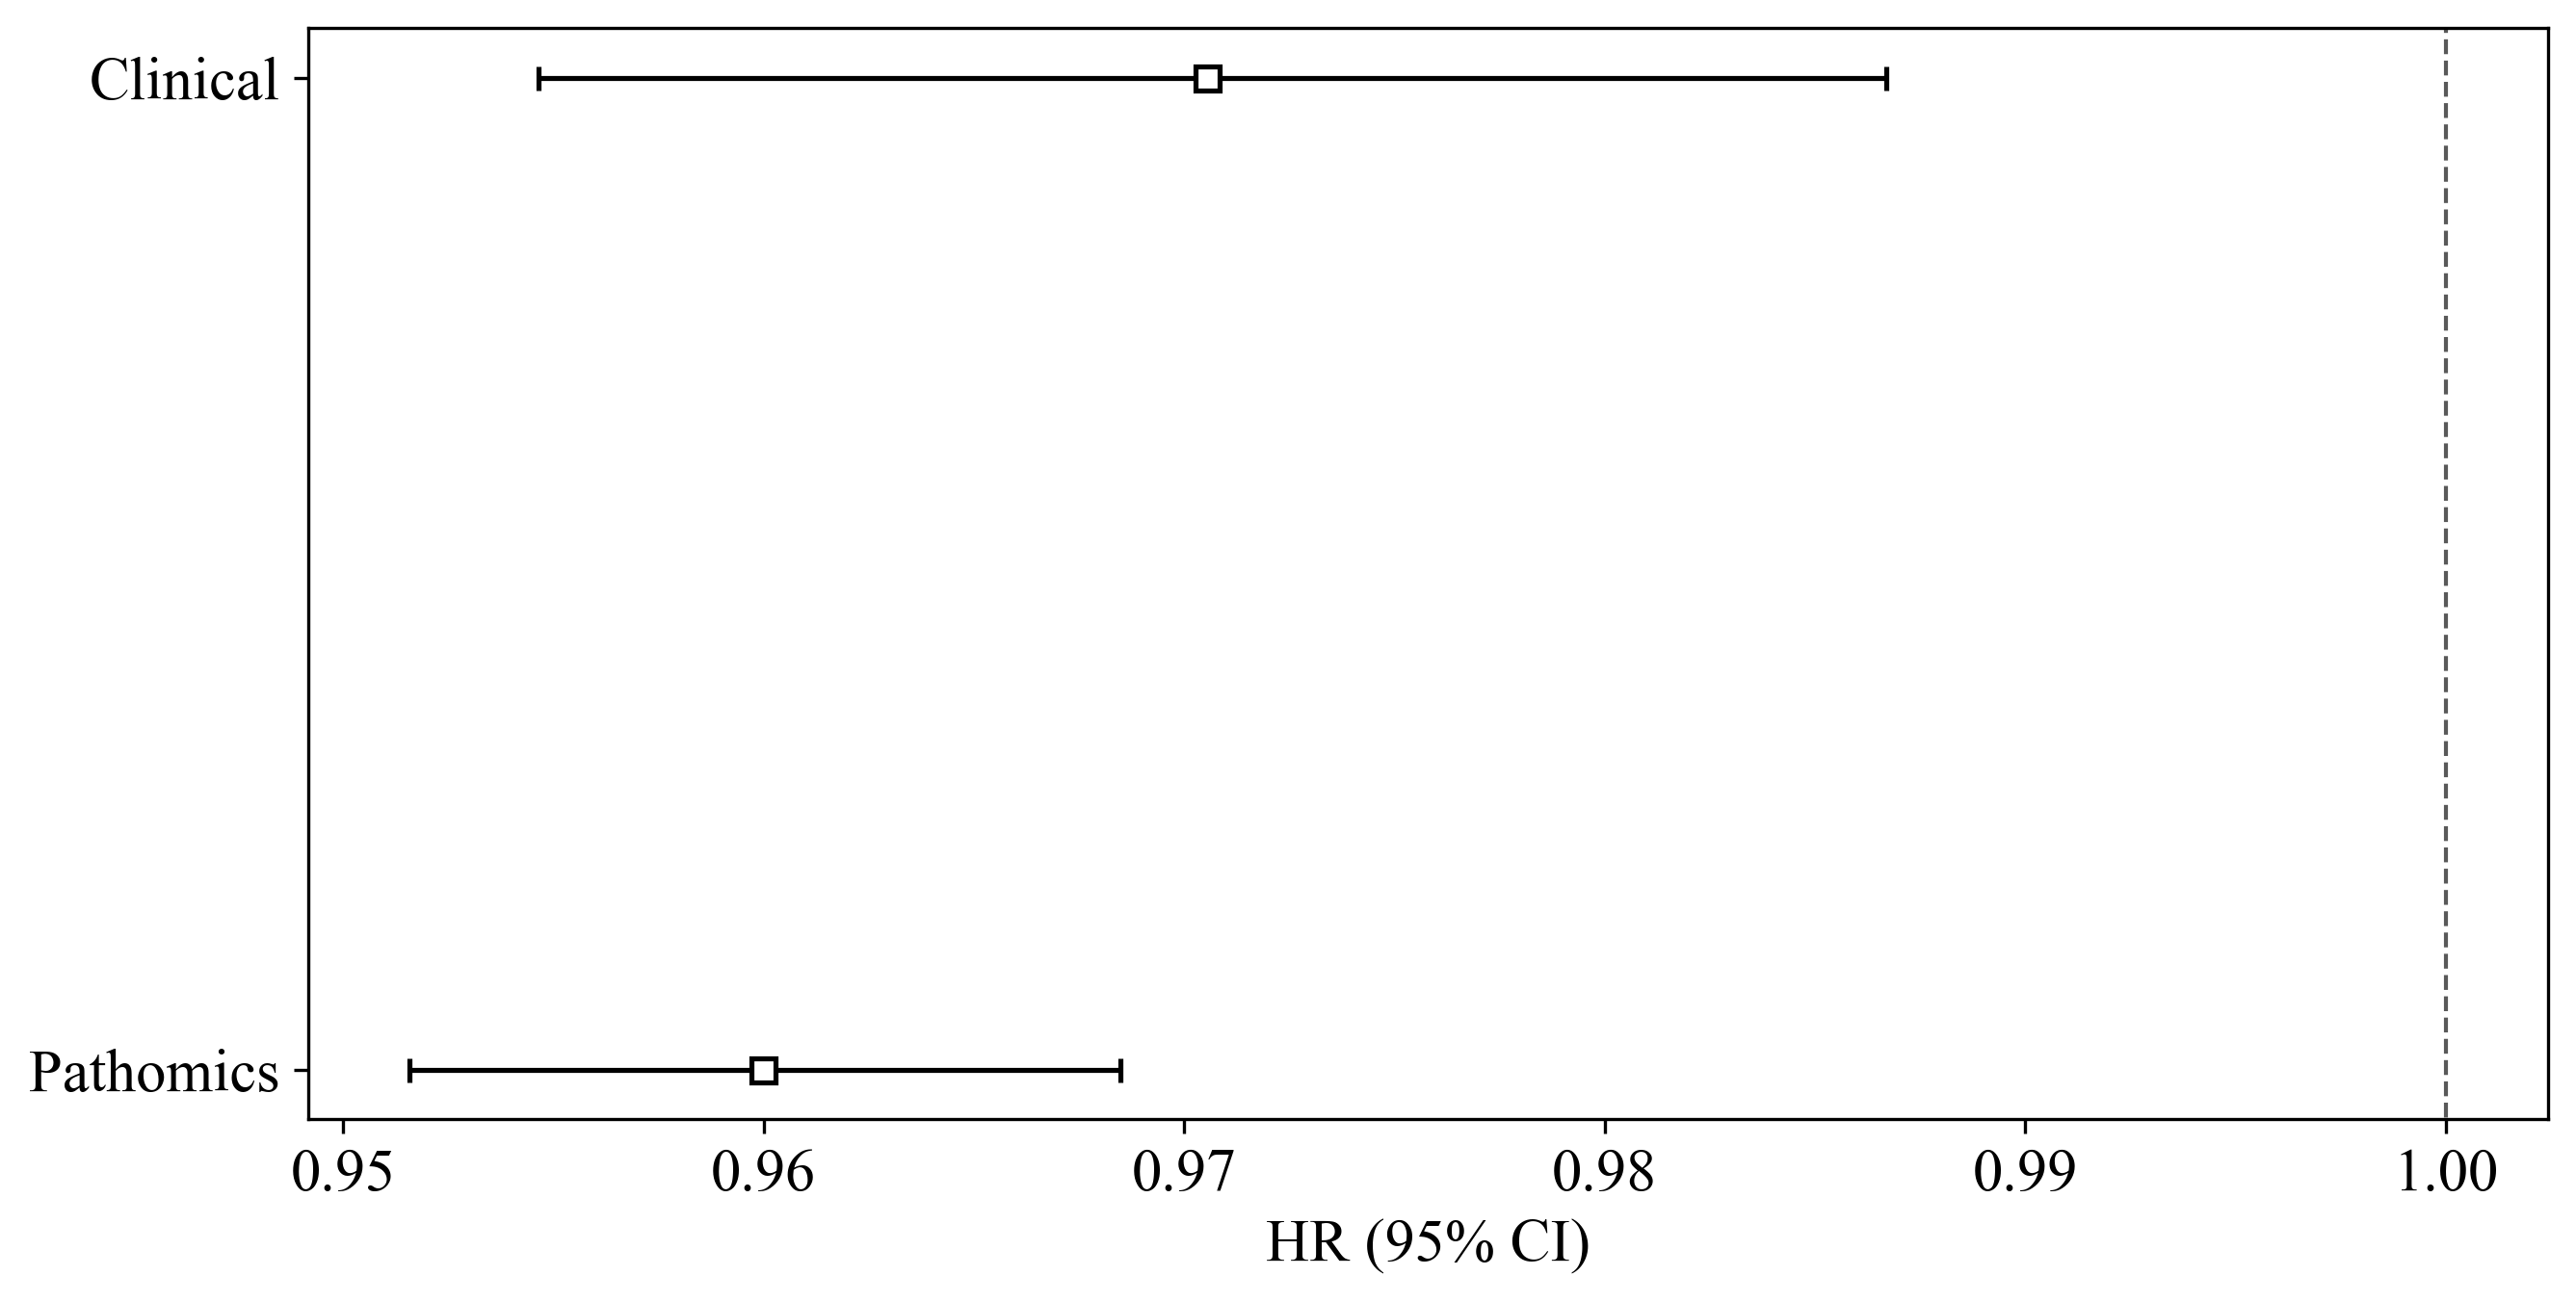

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
cph.plot(hazard_ratios=True)
plt.savefig('img/Clinic_feature_pvalue.svg')
plt.show()

[2025-09-12 23:15:11 - situation.py:  41]	INFO	cffi mode is CFFI_MODE.ANY
[2025-09-12 23:15:11 - situation.py: 227]	INFO	R home found: C:\OnekeyPlatform\onekey_envs\Lib\R
[2025-09-12 23:15:11 - embedded.py:  20]	INFO	Default options to initialize R: rpy2, --quiet, --no-save


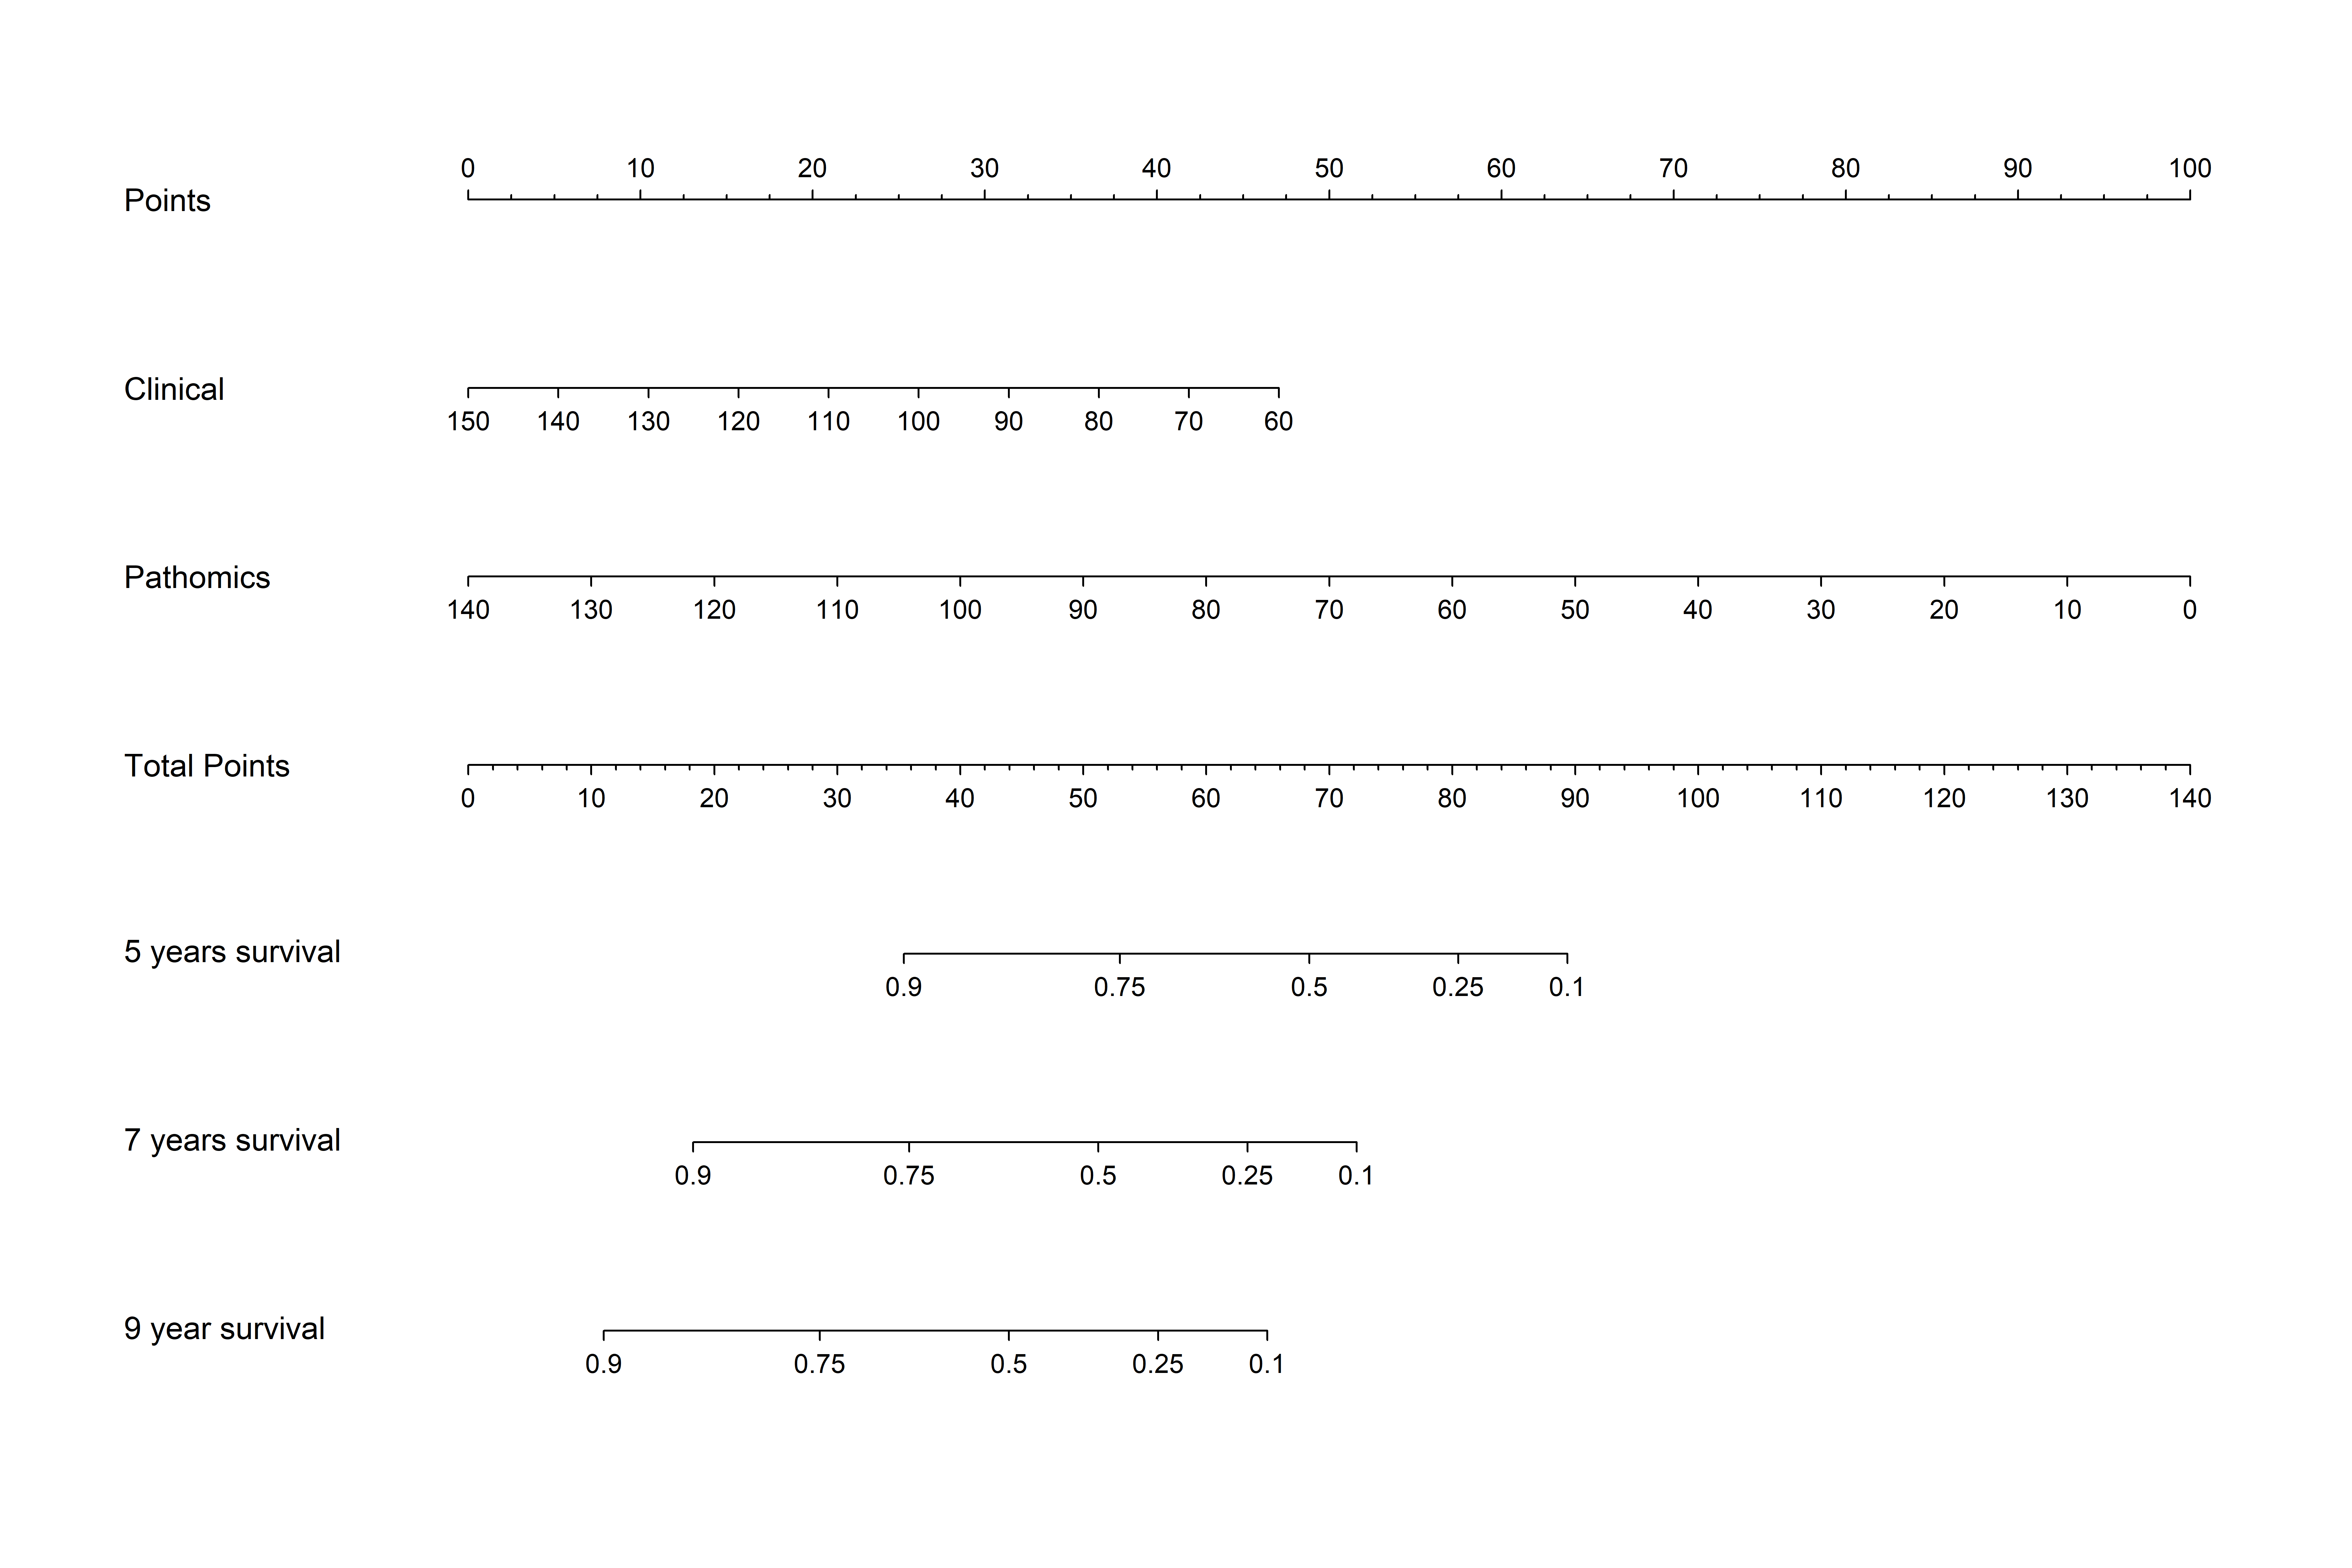

In [8]:
from onekey_algo.custom.components import nomogram

cox_data = train_data.round(decimals=2)
nomogram.nomogram(train_data, duration=duration_col, result=event_col, 
                  columns=[c for c in train_data.columns if c not in ['ID', 'group', duration_col, event_col]],
                  survs=[ 12*5, 12*7, 12*9,], surv_names=['5 years survival', '7 years survival','9 year survival',], with_r=False,
                  width=7500, height=5000, save_name=f'img/nomogram.png',
                  x_range='0.1,0.25,0.5,0.75,0.9')

# nomogram.risk_nomogram(cox_data, result='survival', columns=['Clinic_Sig', 'Rad_Sig'])

# KM 曲线

根据HR进行分组，计算KM以及log ranktest

In [9]:
from onekey_algo.custom.components.ugly import drop_survival

# del_num = {'val': 68, 'test': 5,}
# for subset in ['test']:
#     val_data = val_datasets[subset]
#     cox_data = val_data[[c for c in val_data.columns if c not in ['group']]]
#     kid = drop_survival(cox_data, cph, drop_num=del_num[subset], is_drop_ids=False)
#     display(val_data[~val_data['ID'].isin(kid['ID'])])
#     val_data = pd.merge(val_data, kid[['ID']], on='ID', how='inner')
#     val_datasets[subset] = val_data
#     val_datasets[subset+'_sel'] = val_data

print('，'.join([f"{subset}样本数：{d_.shape[0]}" for subset, d_ in val_datasets.items()]))

train样本数：194，test样本数：84


In [10]:
# from lifelines import CoxPHFitter
# mci = 0
# for p in range(100):
#     cph = CoxPHFitter(penalizer=p/100)
#     cph.fit(train_data[[c for c in train_data.columns if c not in ['ID', 'group']]], duration_col=duration_col, event_col=event_col)
#     test_data = val_datasets['CY']
#     ci = cph.score(test_data[[c for c in test_data.columns if c not in ['ID', 'group']]], scoring_method="concordance_index")
#     if mci < ci:
#         print(p, ci)
#         mci = ci

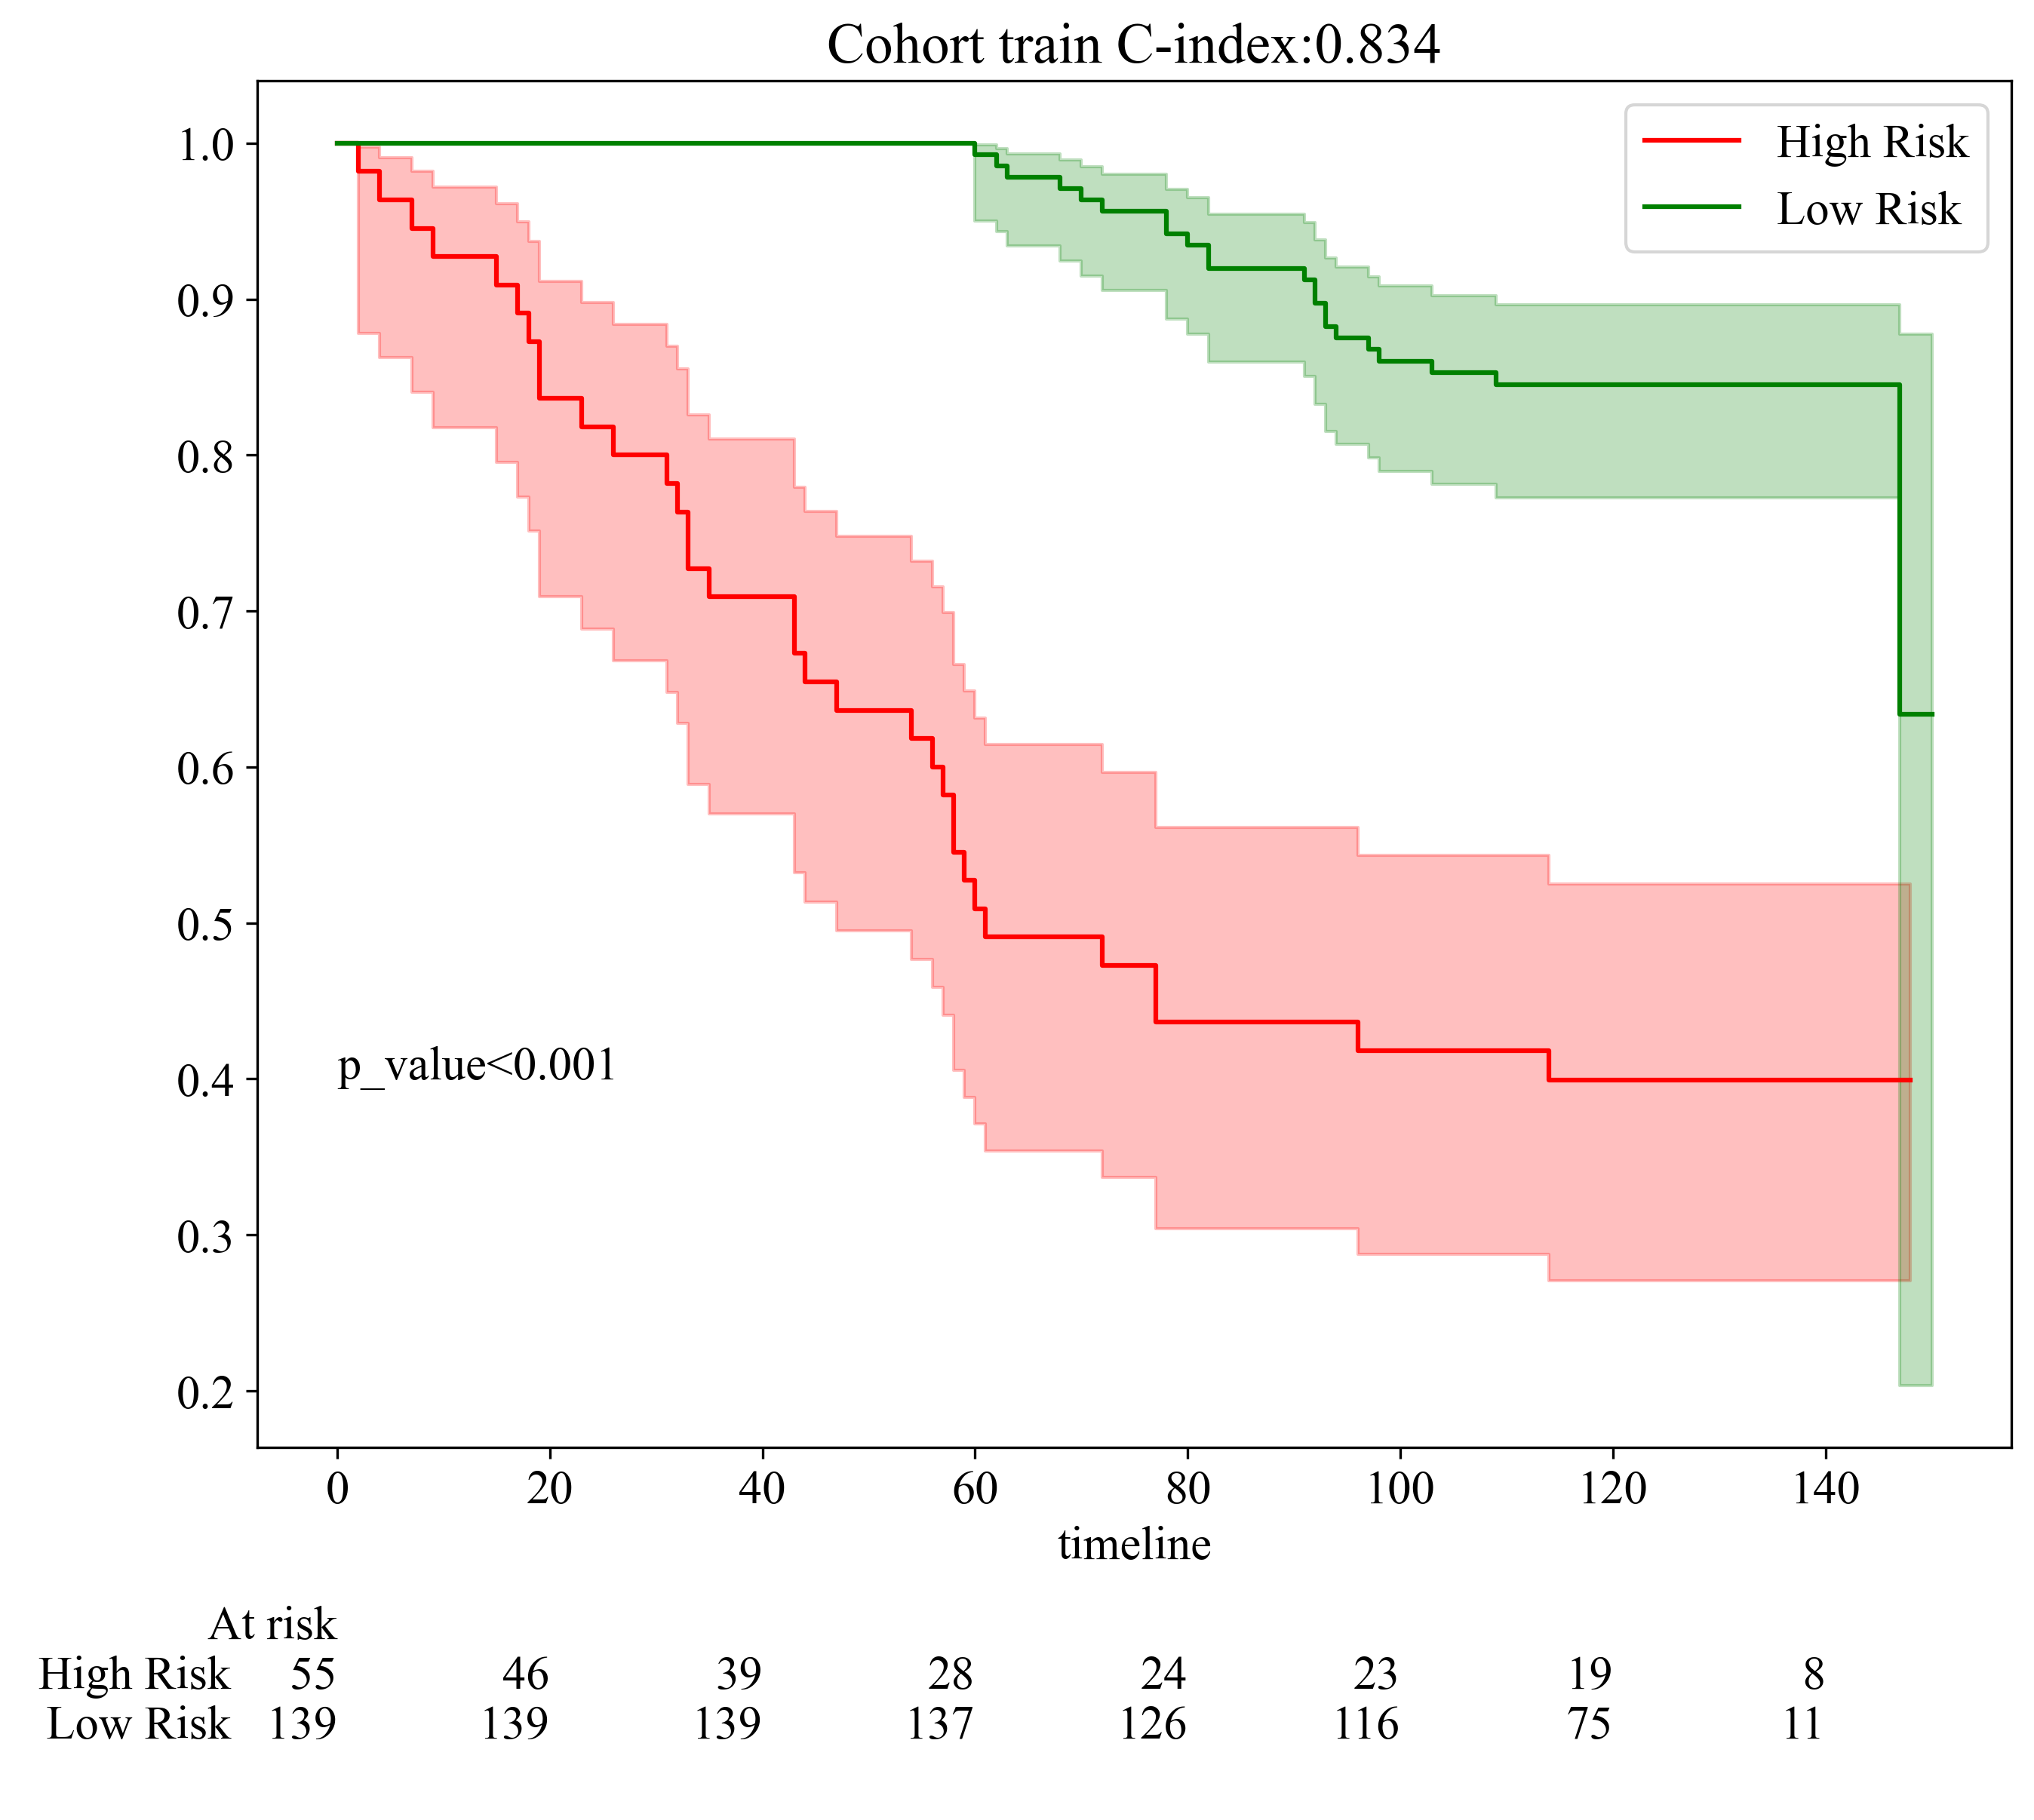

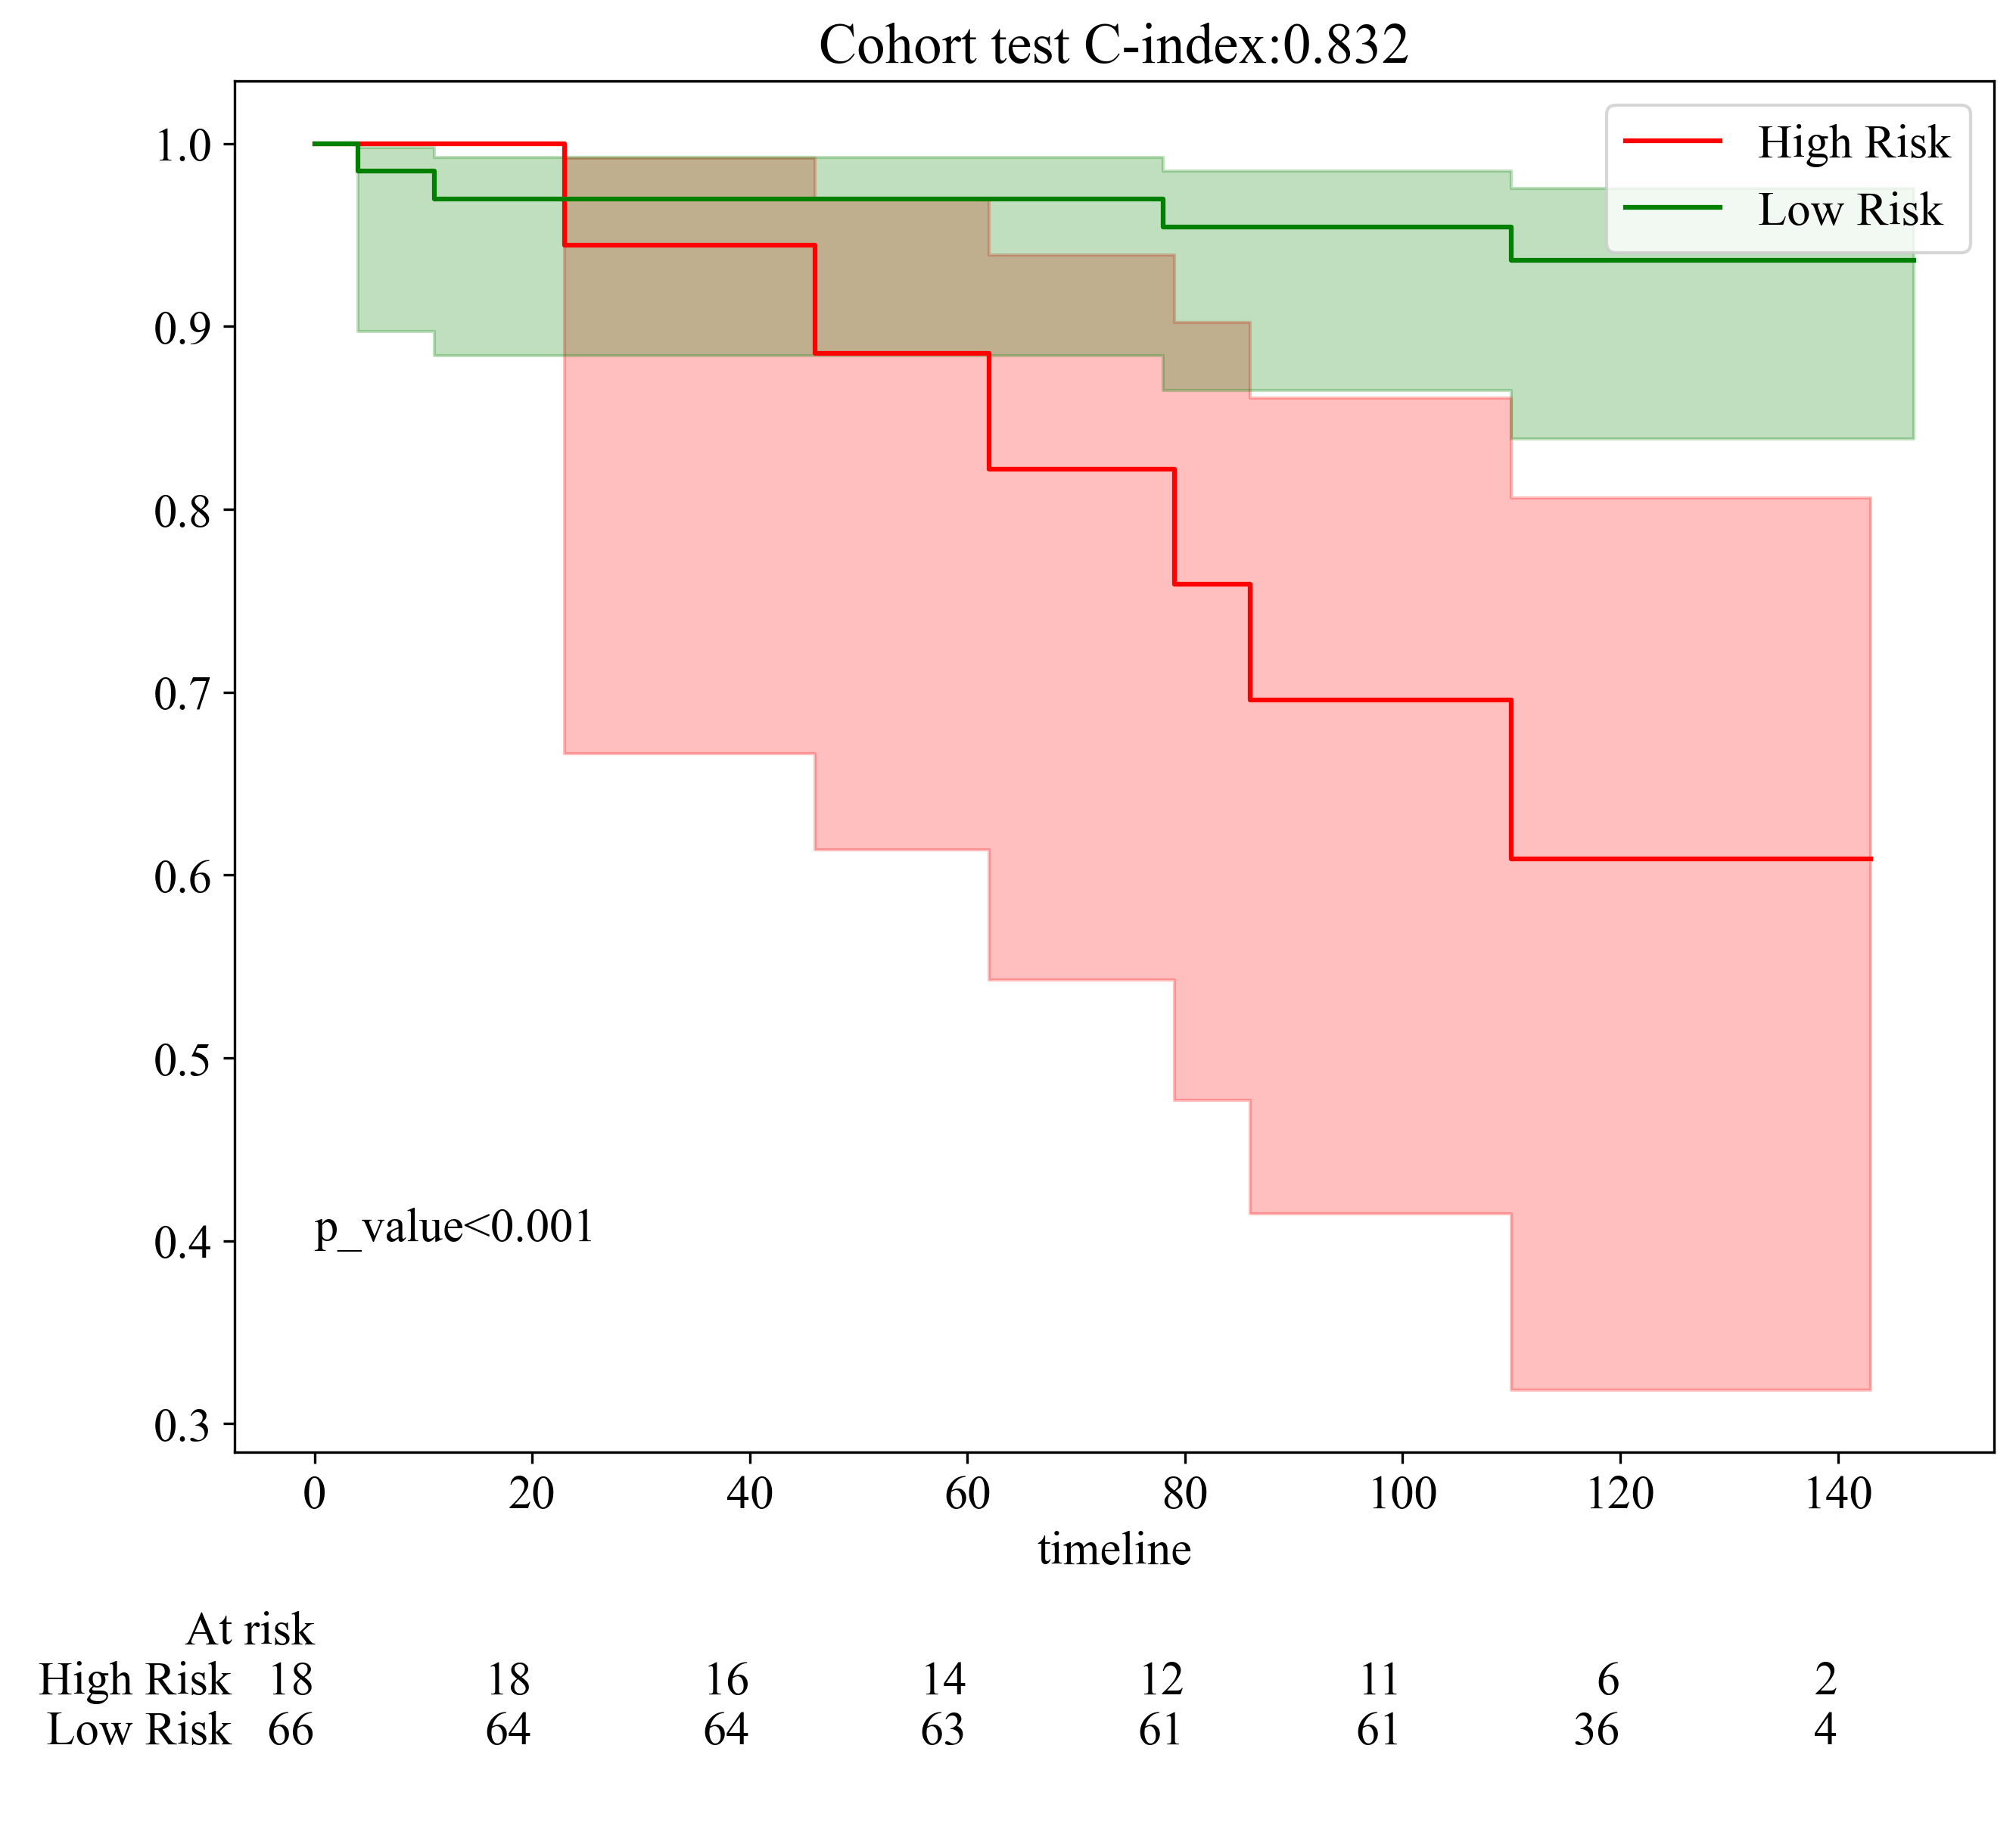

In [13]:
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

thres = 0.001
bst_split = {'train': 1.03, 'val': 1., 'test': 0.97, 'KH':1.01, 'CY':2.24}
loc = {'train': 0.4, 'val':0.2, 'test': 0.4, 'KH':0.2, 'CY':0.2}
for subset, test_data in val_datasets.items():
    c_index = cph.score(test_data[[c for c in test_data.columns if c != 'ID']], scoring_method="concordance_index")
#     y_pred = cph.predict_median(test_data[[c for c in test_data.columns if c != 'ID']])
#     cox_data = pd.concat([test_data, y_pred], axis=1)
#     mean = cox_data.describe()[0.5]['mean']
#     cox_data['HR'] = cox_data[0.5] < mean
    y_pred = cph.predict_partial_hazard(test_data[[c for c in test_data.columns if c != 'ID']])
    cox_data = pd.concat([test_data, y_pred], axis=1)
    mean = cox_data.describe()[0]['50%']
    cox_data['HR'] = cox_data[0] > bst_split[subset] if subset in bst_split else 1
#     cox_data['HR'] = cox_data[0] > mean

    dem = (cox_data["HR"] == True)
    results = logrank_test(cox_data[duration_col][dem], cox_data[duration_col][~dem], 
                           event_observed_A=cox_data[event_col][dem], event_observed_B=cox_data[event_col][~dem])
    p_value = f"={results.p_value:.4f}" if results.p_value > thres else f'<{thres}'
    plt.title(f"Cohort {subset} C-index:{c_index:.3f}")
    if sum(dem):
        kmf_high = KaplanMeierFitter()
        kmf_high.fit(cox_data[duration_col][dem], event_observed=cox_data[event_col][dem], label="High Risk")
        kmf_high.plot_survival_function(color='r')
    if sum(~dem):
        kmf_low = KaplanMeierFitter()
        kmf_low.fit(cox_data[duration_col][~dem], event_observed=cox_data[event_col][~dem], label="Low Risk")
        kmf_low.plot_survival_function(color='g')
    plt.text(0.0, loc[subset] if subset in loc else 0.2, f"p_value{p_value}")
    add_at_risk_counts(kmf_high, kmf_low, rows_to_show=['At risk'])
    plt.savefig(f'img/{task_type}KM_{subset}.svg', bbox_inches='tight')
    plt.show()

In [12]:
import os
import numpy as np

def get_prediction(model: CoxPHFitter, data, ID=None, **kwargs):
    hr = model.predict_partial_hazard(data)
    expectation = model.predict_expectation(data)
    
    predictions = pd.concat([hr, expectation], axis=1)
    predictions.columns = ['HR', 'expectation']
    if ID is not None:
        predictions = pd.concat([ID, hr, expectation], axis=1)
        predictions.columns = ['ID', 'HR', 'expectation']
    else:
        predictions = pd.concat([hr, expectation], axis=1)
        predictions.columns = ['HR', 'expectation']
    return predictions

os.makedirs('results', exist_ok=True)
info = []
for subset, test_data in val_datasets.items():
    if subset in get_param_in_cwd('subsets'):
        results = get_prediction(cph, test_data, ID=test_data['ID'])
        results.to_csv(f'results/{task_type}cox_predictions_{subset}.csv', index=False)
        results['group'] = subset
        info.append(results)
        pd.merge(results, data[['ID', event_col, duration_col]], 
                 on='ID', how='inner').to_csv(f'features/{task_type}4xtile_{subset}.txt', index=False, sep='\t')
info = pd.concat(info, axis=0)
info

,ID,HR,expectation,group
0,J07A3054,0.398,139.370,train
1,J07A3055,0.399,139.346,train
2,J07A3056,0.547,136.351,train
3,J07A3057,0.481,137.676,train
4,J07A3060,0.705,133.272,train
...,...,...,...,...
273,J07A1132,0.369,139.953,test
274,J07A1133,0.477,137.749,test
275,J07A1062,0.385,139.635,test
276,J07A1080,0.360,140.143,test
